# Workflow Overview: SPI-12 Computation from Bias-Corrected Climate Models

This notebook implements a complete, reproducible workflow to compute the 12-month Standardized Precipitation Index (SPI-12) from bias-corrected CMIP6 precipitation outputs and to summarize drought characteristics across multiple models and scenarios.

The analysis proceeds through the following steps:

---

## Step 1: Discover and Inspect Bias-Corrected NetCDF Files
- Recursively search the bias-corrected precipitation directory for all NetCDF (`.nc`) files.
- Inspect the structure of a representative file to confirm variable names, spatial dimensions, and time coverage.

**Purpose:** Ensure data availability and consistency before processing.

---

## Step 2: Merge Yearly NetCDF Files by Climate Model
- Group NetCDF files by climate model.
- Merge all available yearly files into a single continuous NetCDF file per model.
- Sort data chronologically and save one merged file per model.

**Purpose:** Create a continuous time series per model to facilitate temporal analysis.

---

## Step 3: Derive Basin-Mean Monthly Precipitation
- Subset merged NetCDF files to the analysis period (2015–2100).
- Aggregate precipitation to monthly totals.
- Compute the spatial mean across all grid cells.
- Export basin-averaged monthly precipitation time series to CSV files.

**Purpose:** Convert gridded model outputs into basin-scale monthly precipitation suitable for SPI calculation.

---

## Step 4: Compute SPI-12 Time Series
- Apply a 12-month rolling accumulation to monthly precipitation.
- Fit a Gamma distribution to the accumulated precipitation series.
- Transform cumulative probabilities to standard normal values to obtain SPI-12.
- Repeat for all models and scenarios and combine results into a single dataset.

**Purpose:** Quantify long-term meteorological drought conditions consistently across models.

---

## Step 5: Save SPI-12 Outputs
- Export the combined SPI-12 time series for all models and scenarios to an Excel file.

**Purpose:** Enable transparent inspection, plotting, and downstream analysis.

---

## Step 6: Extract Drought Characteristics
- Identify drought months using SPI-12 < −1.0.
- Compute drought metrics for each model and scenario:
  - Drought frequency
  - Mean drought duration
  - Mean drought severity
- Save drought summary statistics to an Excel file.

**Purpose:** Compare drought behavior across climate models in a quantitative manner.

---

## Step 7: Select Representative Climate Models
- Rank models within each scenario based on drought frequency.
- Select three representative models:
  - Dry (highest drought frequency)
  - Median
  - Wet (lowest drought frequency)
- Save selected models to a summary table.

**Purpose:** Reduce ensemble complexity while preserving drought variability.

---

## Step 8: Visualize SPI-12 Time Series
- Plot SPI-12 for all models by scenario.
- Highlight selected representative models against the full ensemble.
- Generate a two-panel figure (SSP2-4.5 and SSP5-8.5) suitable for publication.

**Purpose:** Visually assess inter-model spread and representative drought trajectories.

---

## Outputs
- Merged NetCDF files per model
- Monthly basin-mean precipitation CSVs
- SPI-12 time series (Excel)
- Drought summary metrics (Excel)
- Publication-quality SPI-12 figures

---

This structured workflow ensures transparency, reproducibility, and consistency in multi-model SPI-based drought analysis.


In [ ]:
import glob

files = glob.glob(
    r"\drought data\SPI code\bias_corrected\**\*.nc",           # CHANGE THIS TO YOUR PATH
    recursive=True
)

print(f"✅ Found {len(files)} files")
print("\n".join(files[:5]))  # show a few


In [82]:
import xarray as xr

ds = xr.open_dataset(files[0])
print(ds)


<xarray.Dataset> Size: 19MB
Dimensions:  (lat: 100, lon: 65, time: 365)
Coordinates:
  * lat      (lat) float64 800B -3.875 -3.625 -3.375 ... 20.38 20.62 20.88
  * lon      (lon) float64 520B 23.62 23.88 24.12 24.38 ... 39.12 39.38 39.62
  * time     (time) datetime64[ns] 3kB 2015-01-01 2015-01-02 ... 2015-12-31
Data variables:
    pr       (time, lat, lon) float64 19MB ...


In [ ]:
import os
import xarray as xr
import glob

base_dir = r"\drought data\SPI code\bias_corrected"                 # CHANGE THIS TO YOUR PATH
output_dir = r"\drought data\SPI code\merged_models"                 # CHANGE THIS TO YOUR PATH
os.makedirs(output_dir, exist_ok=True)

# Step 1: Loop through each model folder
models = [d for d in glob.glob(base_dir + r"\*") if os.path.isdir(d)]

for model_path in models:
    model_name = os.path.basename(model_path)
    nc_files = glob.glob(model_path + r"\**\*.nc", recursive=True)

    if len(nc_files) == 0:
        continue

    try:
        print(f"📦 Merging files for model: {model_name} ({len(nc_files)} years)")
        ds = xr.open_mfdataset(nc_files, combine='by_coords')
        ds = ds.sortby('time')  # ensure chronological order

        output_path = os.path.join(output_dir, f"{model_name}_merged.nc")
        ds.to_netcdf(output_path)
        print(f"✅ Saved merged file: {output_path}")

    except Exception as e:
        print(f"❌ Failed to merge {model_name}: {e}")


📦 Merging files for model: ACCESS-CM2 (172 years)


C:\Users\dhb3354\AppData\Local\Temp\ipykernel_36300\881304646.py:25: SerializationWarning: saving variable spatial_ref with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds.to_netcdf(output_path)
C:\Users\dhb3354\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\core\duck_array_ops.py:230: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


✅ Saved merged file: D:\SWAT5-1-2025\Doaa_swat\BlueNile\merged_models\ACCESS-CM2_merged.nc
📦 Merging files for model: ACCESS-ESM1-5 (172 years)


C:\Users\dhb3354\AppData\Local\Temp\ipykernel_36300\881304646.py:25: SerializationWarning: saving variable spatial_ref with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds.to_netcdf(output_path)
C:\Users\dhb3354\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\core\duck_array_ops.py:230: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


✅ Saved merged file: D:\SWAT5-1-2025\Doaa_swat\BlueNile\merged_models\ACCESS-ESM1-5_merged.nc
📦 Merging files for model: BCC-CSM2-MR (172 years)


...

✅ Saved merged file: D:\SWAT5-1-2025\Doaa_swat\BlueNile\merged_models\NorESM2-LM_merged.nc
📦 Merging files for model: NorESM2-MM (172 years)


C:\Users\dhb3354\AppData\Local\Temp\ipykernel_36300\881304646.py:25: SerializationWarning: saving variable spatial_ref with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds.to_netcdf(output_path)
C:\Users\dhb3354\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\core\duck_array_ops.py:230: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


✅ Saved merged file: D:\SWAT5-1-2025\Doaa_swat\BlueNile\merged_models\NorESM2-MM_merged.nc
📦 Merging files for model: TaiESM1 (171 years)


C:\Users\dhb3354\AppData\Local\Temp\ipykernel_36300\881304646.py:25: SerializationWarning: saving variable spatial_ref with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds.to_netcdf(output_path)
C:\Users\dhb3354\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xarray\core\duck_array_ops.py:230: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


✅ Saved merged file: D:\SWAT5-1-2025\Doaa_swat\BlueNile\merged_models\TaiESM1_merged.nc


In [ ]:
import xarray as xr
import pandas as pd
import glob
import os

input_dir = r"\merged_models"              # CHANGE THIS TO YOUR PATH
output_dir = r"\monthly_csv"               # CHANGE THIS TO YOUR PATH
os.makedirs(output_dir, exist_ok=True)

files = glob.glob(input_dir + r"\*_merged.nc")

for f in files:
    try:
        model_name = os.path.basename(f).replace("_merged.nc", "")
        print(f"🔄 Converting {model_name}...")

        ds = xr.open_dataset(f)
        ds = ds.sortby("time")

        # Optional: future-only time filter
        ds = ds.sel(time=slice("2015-01-01", "2100-12-31"))

        # Convert to monthly total precipitation
        monthly = ds["pr"].resample(time='MS').sum()

        # Spatial average (mean over lat/lon)
        mean_monthly = monthly.mean(dim=["lat", "lon"])

        # Convert to DataFrame
        df = mean_monthly.to_dataframe(name='precip').reset_index()
        df['model'] = model_name
        df['year'] = df['time'].dt.year
        df['month'] = df['time'].dt.month

        # Reorder columns
        df = df[['model', 'year', 'month', 'precip']]

        # Save CSV
        csv_path = os.path.join(output_dir, f"{model_name}_monthly_precip.csv")
        df.to_csv(csv_path, index=False)

        print(f"✅ Saved to: {csv_path}")

    except Exception as e:
        print(f"❌ Failed for {f}: {e}")


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

# === Function to compute SPI-12 ===
def compute_spi12(pr_series):
    pr_series = pr_series.replace(0, np.nan).dropna()
    if pr_series.empty or len(pr_series) < 12:
        return pd.Series(index=pr_series.index, dtype='float64')

    rolling_sum = pr_series.rolling(window=12).sum()
    valid_data = rolling_sum.dropna()

    if valid_data.empty:
        return pd.Series(index=pr_series.index, dtype='float64')

    shape, loc, scale = gamma.fit(valid_data, floc=0)
    cdf = gamma.cdf(valid_data, a=shape, loc=loc, scale=scale)
    spi = pd.Series(norm.ppf(cdf), index=valid_data.index)

    full_spi = pd.Series(index=pr_series.index, dtype='float64')
    full_spi.loc[spi.index] = spi
    return full_spi

# === Your data directory ===
data_dir = r"\bias_corrected\precipitation data\models_split_by_scenario"                 # CHANGE THIS TO YOUR PATH

# === Process each file ===
all_spi = []

for file_name in os.listdir(data_dir):
    if file_name.endswith(".csv"):
        file_path = os.path.join(data_dir, file_name)
        df = pd.read_csv(file_path)

        # Create datetime and clean duplicates
        df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
        df = df.groupby('date', as_index=True)['pr'].mean().to_frame()

        # Compute SPI-12
        spi_series = compute_spi12(df['pr'])

        # Parse model and scenario from filename
        base = os.path.splitext(file_name)[0]
        if '_' in base:
            model, scenario = base.split('_', 1)
        else:
            model, scenario = base, 'unknown'

        # Store result
        result = pd.DataFrame({
            'date': spi_series.index,
            'spi12': spi_series.values,
            'model': model,
            'scenario': scenario
        })
        all_spi.append(result)

# === Combine all into one DataFrame ===
spi_all_df = pd.concat(all_spi, ignore_index=True)

# === Plot for each


In [ ]:
# === Save all SPI results to Excel ===
output_path = r"\drought data\SPI code\SPI_12_all_models.xlsx"         # CHANGE THIS TO YOUR PATH
spi_all_df.to_excel(output_path, index=False)
print(f"✅ SPI-12 results saved to: {output_path}")


In [ ]:
import numpy as np

# Filter out NaNs
spi_valid = spi_all_df.dropna(subset=['spi12'])

# Define drought threshold
drought_threshold = -1.0

# Function to analyze drought duration and severity per group
def analyze_drought(group):
    droughts = group['spi12'] < drought_threshold
    group['drought_flag'] = droughts.astype(int)

    # Count drought frequency
    freq = droughts.sum()

    # Calculate drought durations
    durations = []
    severity = []
    current_duration = 0
    current_severity = 0

    for value in group['spi12']:
        if value < drought_threshold:
            current_duration += 1
            current_severity += value
        else:
            if current_duration > 0:
                durations.append(current_duration)
                severity.append(current_severity)
                current_duration = 0
                current_severity = 0

    # Handle final sequence
    if current_duration > 0:
        durations.append(current_duration)
        severity.append(current_severity)

    return pd.Series({
        'drought_frequency': freq,
        'mean_drought_duration': np.mean(durations) if durations else 0,
        'mean_drought_severity': np.mean(severity) if severity else 0
    })

# Apply per model and scenario
drought_summary = spi_valid.groupby(['model', 'scenario'], group_keys=False).apply(analyze_drought).reset_index()


# Save results
drought_summary_path = r"\drought_summary_SPI12.xlsx"               # CHANGE THIS TO YOUR PATH
drought_summary.to_excel(drought_summary_path, index=False)

print(f"✅ Drought summary saved to: {drought_summary_path}")


In [ ]:
import pandas as pd
import numpy as np
import os

# === Load drought summary ===
summary_path = r"\drought_summary_SPI12.xlsx"                        # CHANGE THIS TO YOUR PATH
drought_summary = pd.read_excel(summary_path)

# === Function to select Dry, Median, Wet models ===
def select_representative_models(df, scenario_name):
    subset = df[df['scenario'] == scenario_name].copy()
    subset_sorted = subset.sort_values('drought_frequency', ascending=False).reset_index(drop=True)

    dry_model = subset_sorted.iloc[0]  # most droughts
    wet_model = subset_sorted.iloc[-1]  # least droughts
    median_model = subset_sorted.iloc[len(subset_sorted) // 2]  # typical

    return dry_model, median_model, wet_model

# === Select models for each scenario ===
representative_models = []

for scenario in drought_summary['scenario'].unique():
    dry, median, wet = select_representative_models(drought_summary, scenario)
    
    representative_models.extend([
        {'Scenario': scenario, 'Type': 'Dry', 'Model': dry['model'], 
         'Drought Frequency': dry['drought_frequency'], 
         'Mean Duration': dry['mean_drought_duration'], 
         'Mean Severity': dry['mean_drought_severity']},
        
        {'Scenario': scenario, 'Type': 'Median', 'Model': median['model'], 
         'Drought Frequency': median['drought_frequency'], 
         'Mean Duration': median['mean_drought_duration'], 
         'Mean Severity': median['mean_drought_severity']},
        
        {'Scenario': scenario, 'Type': 'Wet', 'Model': wet['model'], 
         'Drought Frequency': wet['drought_frequency'], 
         'Mean Duration': wet['mean_drought_duration'], 
         'Mean Severity': wet['mean_drought_severity']},
    ])

# === Save to Excel ===
rep_models_df = pd.DataFrame(representative_models)
output_path = r"\drought data\SPI code\representative_drought_models.xlsx"               # CHANGE THIS TO YOUR PATH
rep_models_df.to_excel(output_path, index=False)

print(f"✅ Representative drought models saved to:\n{output_path}")


✅ Representative drought models saved to:
D:\SWAT5-1-2025\Doaa_swat\BlueNile\drought data\SPI code\representative_drought_models.xlsx


In [ ]:
import pandas as pd
import numpy as np

# === Step 1: Load drought summary ===
drought_summary_path = r"\drought_summary_SPI12.xlsx"                        # CHANGE THIS TO YOUR PATH
drought_summary = pd.read_excel(drought_summary_path)

# === Step 2: Select representative models ===
def select_representative_models(df, scenario_name):
    subset = df[df['scenario'] == scenario_name].copy()
    subset_sorted = subset.sort_values('drought_frequency', ascending=False).reset_index(drop=True)
    
    dry_model = subset_sorted.iloc[0]
    wet_model = subset_sorted.iloc[-1]
    median_model = subset_sorted.iloc[len(subset_sorted) // 2]

    return dry_model, median_model, wet_model

# Apply for each scenario
results = []
for scenario in drought_summary['scenario'].unique():
    dry, median, wet = select_representative_models(drought_summary, scenario)
    for model_type, model_data in zip(['Dry', 'Median', 'Wet'], [dry, median, wet]):
        results.append({
            'Scenario': scenario,
            'Type': model_type,
            'Model': model_data['model'],
            'Drought Frequency': model_data['drought_frequency'],
            'Mean Duration': model_data['mean_drought_duration'],
            'Mean Severity': model_data['mean_drought_severity']
        })

# === Step 3: Save results ===
rep_models_df = pd.DataFrame(results)
output_path = r"\drought data\SPI code\representative_models_SPI12.xlsx"               # CHANGE THIS TO YOUR PATH
rep_models_df.to_excel(output_path, index=False)

print(f"✅ Representative models saved to:\n{output_path}")


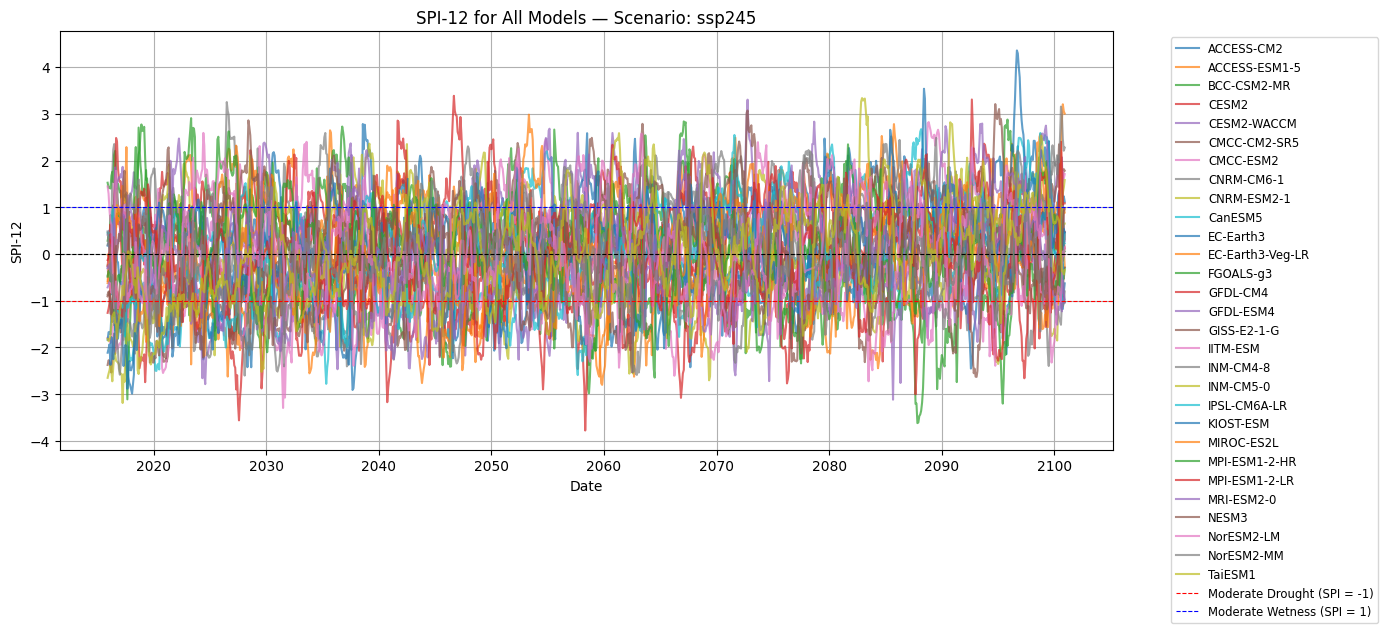

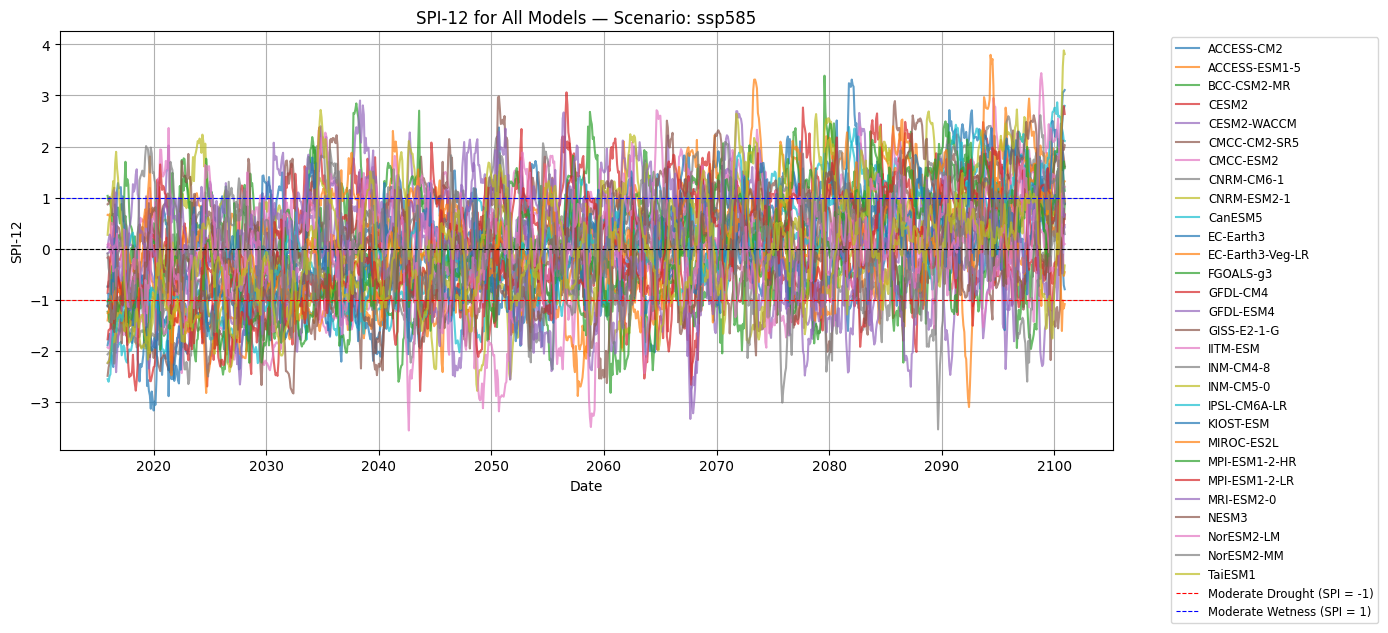

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load SPI-12 data ===
file_path = r"\drought data\SPI code\SPI_12_all_models.xlsx"         # CHANGE THIS TO YOUR PATH
df = pd.read_excel(file_path)

# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# === Plot for each scenario ===
for scenario in df['scenario'].unique():
    plt.figure(figsize=(14, 6))
    scenario_data = df[df['scenario'] == scenario]

    for model in scenario_data['model'].unique():
        model_data = scenario_data[scenario_data['model'] == model]
        plt.plot(model_data['date'], model_data['spi12'], label=model, alpha=0.7)

    plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    plt.axhline(y=-1, color='red', linestyle='--', linewidth=0.8, label='Moderate Drought (SPI = -1)')
    plt.axhline(y=1, color='blue', linestyle='--', linewidth=0.8, label='Moderate Wetness (SPI = 1)')

    plt.title(f"SPI-12 for All Models — Scenario: {scenario}")
    plt.xlabel("Date")
    plt.ylabel("SPI-12")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.grid(True)
    plt.show()


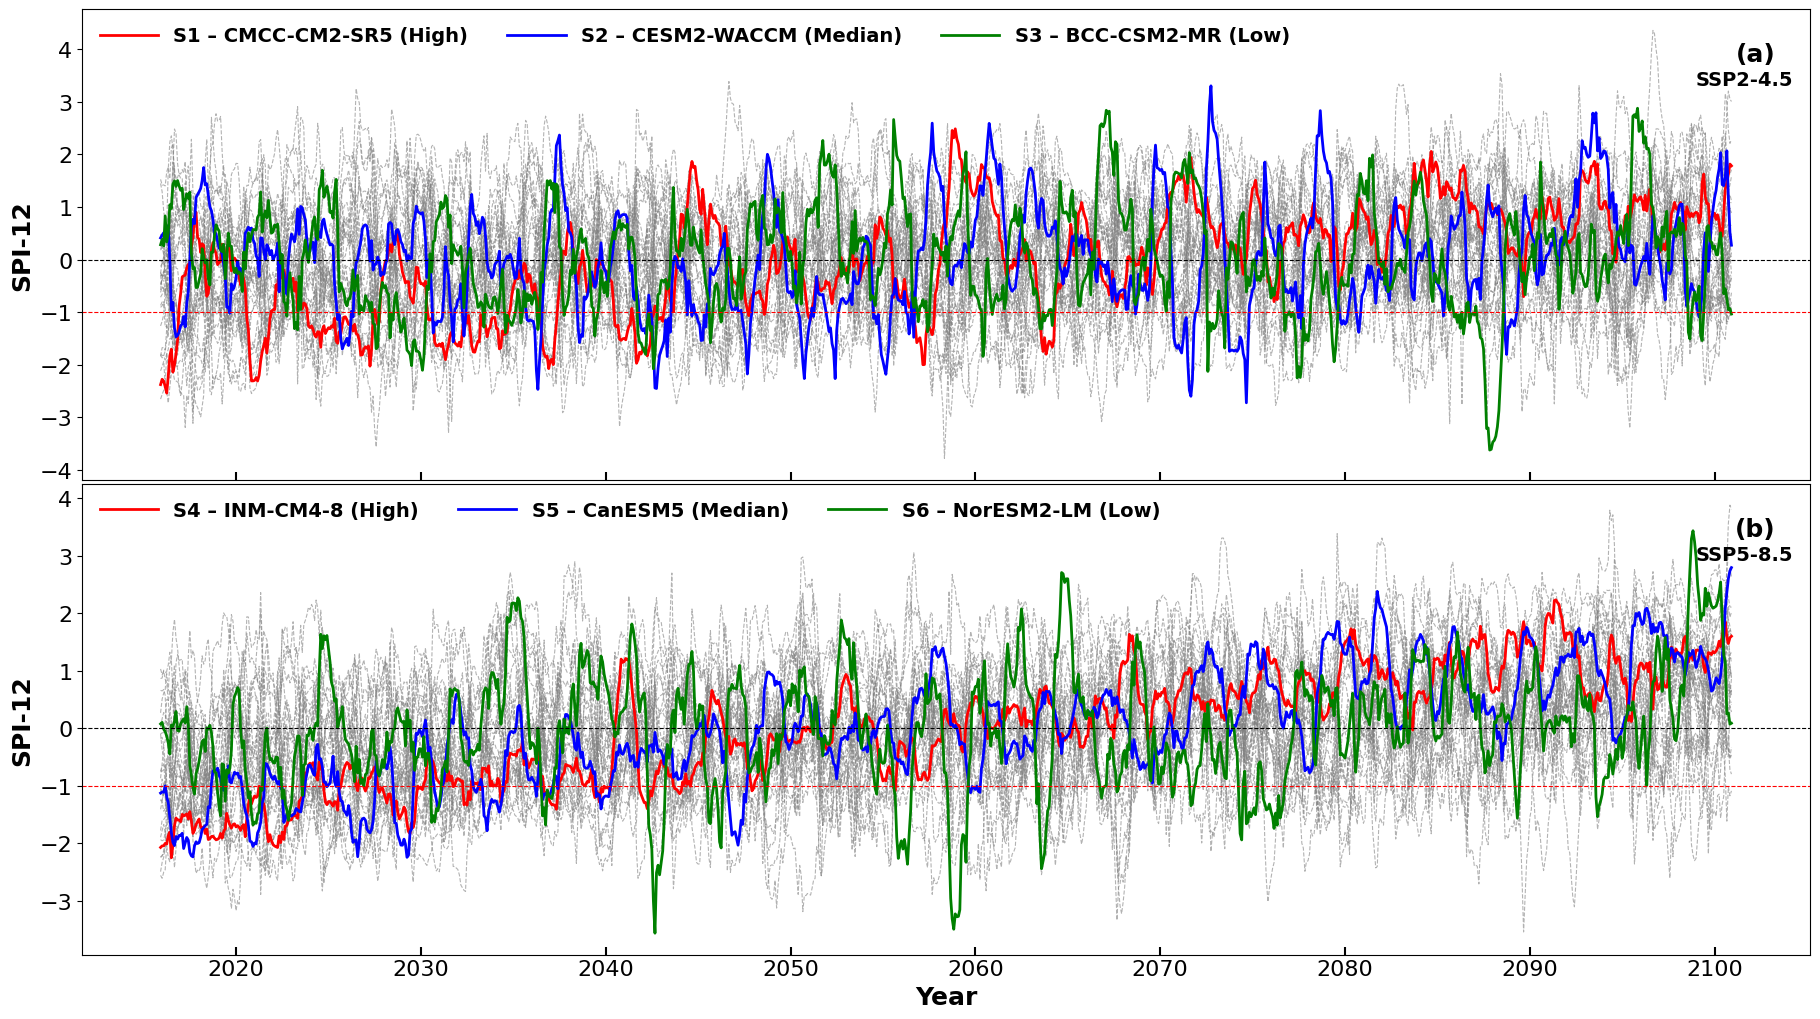

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load SPI-12 data ===
file_path = r"\drought data\SPI code\SPI models selected\SPI_12_all_models.xlsx"        # CHANGE THIS TO YOUR PATH
df = pd.read_excel(file_path)

df["date"] = pd.to_datetime(df["date"])
df = df[df["date"].dt.year <= 2100].copy()

highlight_models = {
    "ssp245": {"High": "CMCC-CM2-SR5", "Median": "CESM2-WACCM", "Low": "BCC-CSM2-MR"},
    "ssp585": {"High": "INM-CM4-8",    "Median": "CanESM5",     "Low": "NorESM2-LM"}
}

model_to_S = {
    "BCC-CSM2-MR": "S3",
    "CESM2-WACCM": "S2",
    "CMCC-CM2-SR5": "S1",
    "CanESM5": "S5",
    "INM-CM4-8": "S4",
    "NorESM2-LM": "S6"
}

colors = {"High": "red", "Median": "blue", "Low": "green"}
panel_label = {"ssp245": "(a)", "ssp585": "(b)"}
scenario_title = {"ssp245": "SSP2-4.5", "ssp585": "SSP5-8.5"}

# === Figure ===
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

for i, scenario in enumerate(["ssp245", "ssp585"]):
    ax = axes[i]
    sdf = df[df["scenario"] == scenario]

    # background models
    for m in sdf["model"].dropna().unique():
        if m not in highlight_models[scenario].values():
            mdf = sdf[sdf["model"] == m]
            ax.plot(mdf["date"], mdf["spi12"],
                    color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

    # highlighted models
    for role, m in highlight_models[scenario].items():
        mdf = sdf[sdf["model"] == m]
        ax.plot(
            mdf["date"], mdf["spi12"],
            color=colors[role], linewidth=2.0,
            label=f"{model_to_S[m]} – {m} ({role})"
        )

    # reference lines
    ax.axhline(0,  color="black", linestyle="--", linewidth=0.8)
    ax.axhline(-1, color="red",   linestyle="--", linewidth=0.8)

    # panel label (a)/(b) top-right
    ax.text(0.98, 0.93, panel_label[scenario],
            transform=ax.transAxes, fontsize=18, fontweight="bold",
            ha="right", va="top")

    ax.set_ylabel("SPI-12", fontsize=18, fontweight="bold")
    ax.tick_params(axis="both", labelsize=16)
    ax.tick_params(axis="x", which="both", direction="in", length=6, width=1.5)

    # legend inside, horizontal (top-left)
    leg = ax.legend(loc="upper left", ncol=3, fontsize=14, frameon=False, handlelength=3)
    for t in leg.get_texts():
        t.set_fontweight("bold")

    # ---- SSP label INSIDE, but BELOW the legend to avoid overlap ----
    ax.text(.99, 0.87, scenario_title[scenario],
            transform=ax.transAxes, fontsize=14, fontweight="bold",
            ha="right", va="top")

    ax.grid(False)

# top panel: remove year numbers (keep tick marks)
axes[0].tick_params(axis="x", which="both", labelbottom=False)

# bottom panel: year label
axes[1].set_xlabel("Year", fontsize=18, fontweight="bold")

# no space between panels
fig.subplots_adjust(hspace=0.0)
plt.tight_layout(pad=0)
plt.show()


In [ ]:
import os
import glob
import pandas as pd

folder = r"\drought data\SPI code\notebooks\Final Tables data\monthly_csv"             # CHANGE THIS TO YOUR PATH

# 1) List everything in the folder (files + subfolders)
print("---- Contents ----")
for name in sorted(os.listdir(folder)):
    path = os.path.join(folder, name)
    print(("DIR " if os.path.isdir(path) else "FILE"), name)

# 2) If you only want CSV files
csv_files = sorted(glob.glob(os.path.join(folder, "*.csv")))
print(f"\nFound {len(csv_files)} CSV files:")
for f in csv_files[:20]:
    print(" -", os.path.basename(f))
if len(csv_files) > 20:
    print(f" ... (+{len(csv_files)-20} more)")

# 3) Read one CSV (example: the first one) and preview
if csv_files:
    df0 = pd.read_csv(csv_files[0])
    print("\n---- Preview of first CSV ----")
    print("File:", os.path.basename(csv_files[0]))
    print(df0.head())
    print("\nColumns:", df0.columns.tolist())
else:
    print("\nNo CSV files found in this folder.")


---- Contents ----
FILE ACCESS-CM2_monthly_precip.csv
FILE ACCESS-ESM1-5_monthly_precip.csv
FILE BCC-CSM2-MR_monthly_precip.csv
FILE CESM2-WACCM_monthly_precip.csv
FILE CESM2_monthly_precip.csv
FILE CMCC-CM2-SR5_monthly_precip.csv
FILE CMCC-ESM2_monthly_precip.csv
FILE CNRM-CM6-1_monthly_precip.csv
FILE CNRM-ESM2-1_monthly_precip.csv
FILE CanESM5_monthly_precip.csv
FILE EC-Earth3-Veg-LR_monthly_precip.csv
FILE EC-Earth3_monthly_precip.csv
FILE FGOALS-g3_monthly_precip.csv
FILE GFDL-CM4_monthly_precip.csv
FILE GFDL-ESM4_monthly_precip.csv
FILE GISS-E2-1-G_monthly_precip.csv
FILE IITM-ESM_monthly_precip.csv
FILE INM-CM4-8_monthly_precip.csv
FILE INM-CM5-0_monthly_precip.csv
FILE IPSL-CM6A-LR_monthly_precip.csv
FILE KIOST-ESM_monthly_precip.csv
FILE MIROC-ES2L_monthly_precip.csv
FILE MPI-ESM1-2-HR_monthly_precip.csv
FILE MPI-ESM1-2-LR_monthly_precip.csv
FILE MRI-ESM2-0_monthly_precip.csv
FILE NESM3_monthly_precip.csv
FILE NorESM2-LM_monthly_precip.csv
FILE NorESM2-MM_monthly_precip.csv
FI